In [ ]:
Задание 8. Вариант 3 Выполнил: Радченко Анатолий Группа: МГК-53

Размер данных: (178, 13)
Признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium'] ...
Классы: ['class_0' 'class_1' 'class_2']
Распределение классов:
 1    71
0    59
2    48
Name: count, dtype: int64
Обучающая выборка: (142, 13)
Тестовая выборка: (36, 13)
=== Логистическая регрессия ===
Accuracy:  0.9722
Precision (macro): 0.9778
Recall (macro):    0.9667
F1-score (macro):  0.9710

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



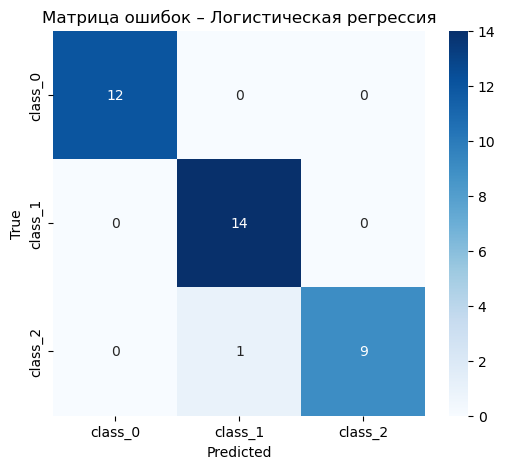

Лучшие параметры: {'max_depth': 3, 'min_samples_split': 2}
Лучшая точность на тесте: 0.9444444444444444
=== Дерево решений (лучшие параметры) ===
Accuracy:  0.9444
Precision (macro): 0.9583
Recall (macro):    0.9389
F1-score (macro):  0.9457

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      0.92      0.96        12
     class_1       0.88      1.00      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



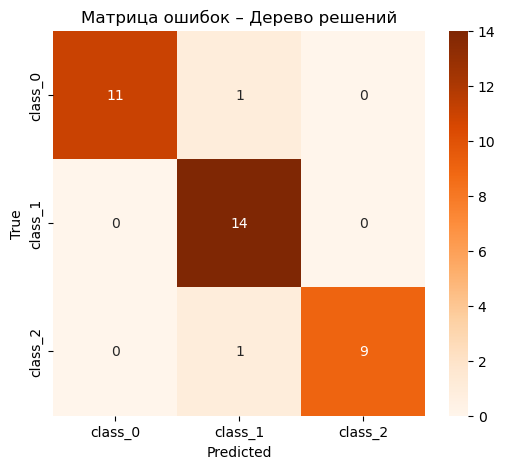

Сравнение критериев:
Gini     – accuracy: 0.9444
Entropy  – accuracy: 0.9722


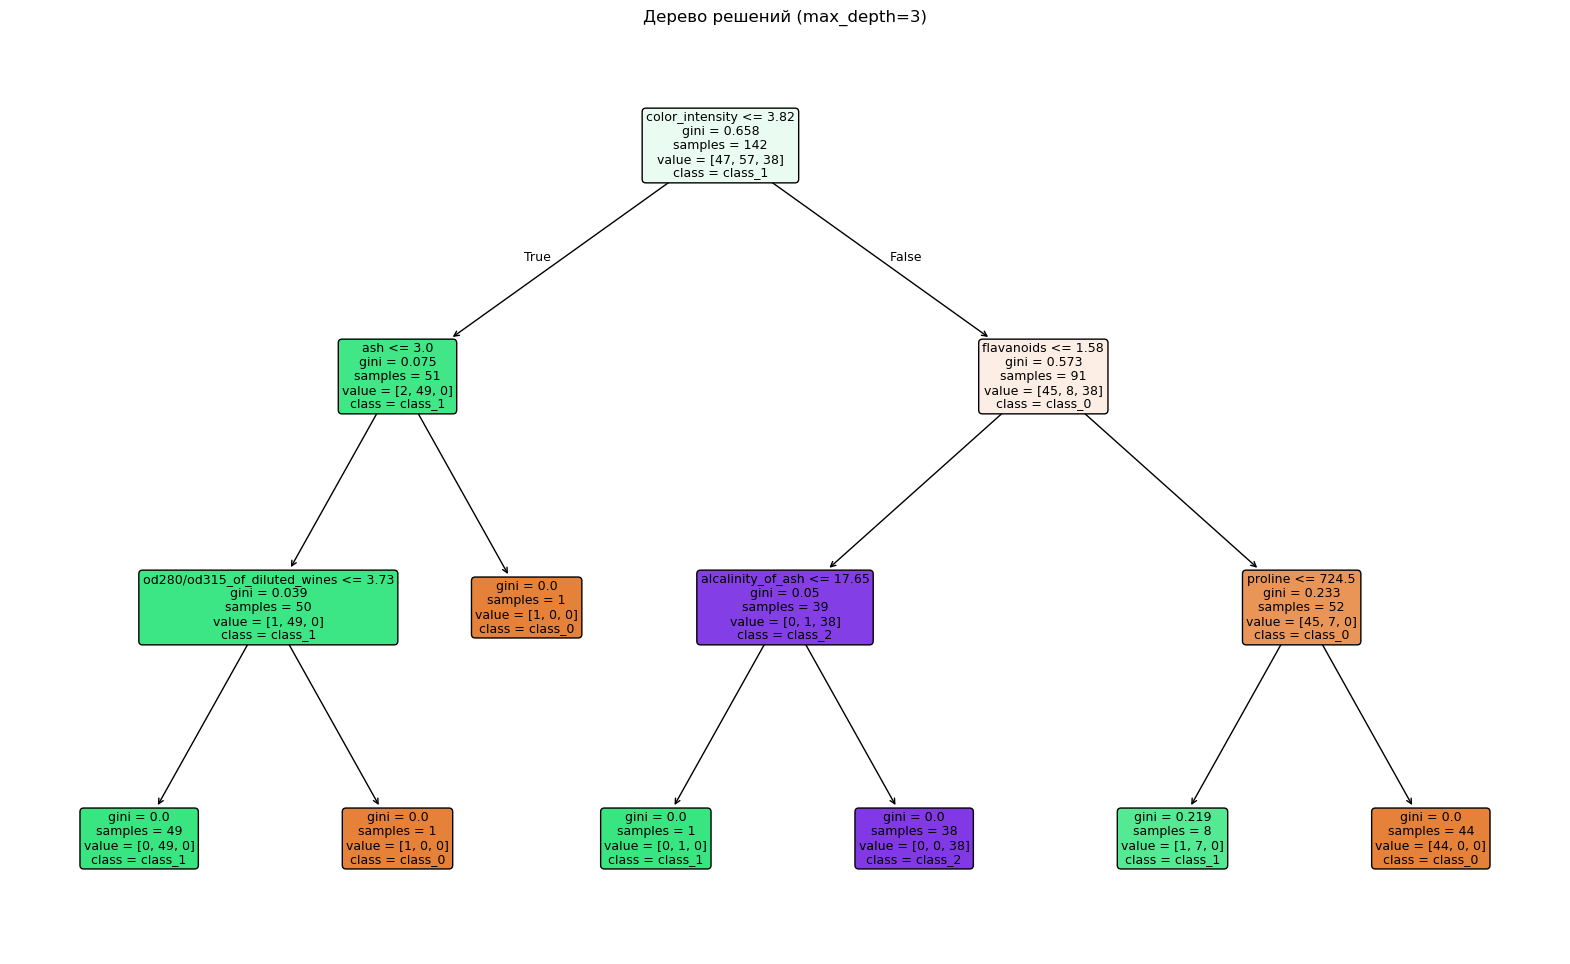


=== Сравнение моделей ===
              Model  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)
Logistic Regression  0.972222           0.977778        0.966667    0.970962
      Decision Tree  0.944444           0.958333        0.938889    0.945741


In [7]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)


wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
class_names = wine.target_names

print("Размер данных:", X.shape)
print("Признаки:", feature_names[:5], "...")
print("Классы:", class_names)
print("Распределение классов:\n", pd.Series(y).value_counts())



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




lr_model = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)


acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, average='macro')
rec_lr = recall_score(y_test, y_pred_lr, average='macro')
f1_lr = f1_score(y_test, y_pred_lr, average='macro')

print("=== Логистическая регрессия ===")
print(f"Accuracy:  {acc_lr:.4f}")
print(f"Precision (macro): {prec_lr:.4f}")
print(f"Recall (macro):    {rec_lr:.4f}")
print(f"F1-score (macro):  {f1_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=class_names))

# Матрица ошибок
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Матрица ошибок – Логистическая регрессия')
plt.show()

depths = [3, 5, 7, 10, None]
splits = [2, 5, 10]

best_score = 0
best_params = {}
train_scores = []

for depth in depths:
    for split in splits:
        dt = DecisionTreeClassifier(max_depth=depth, min_samples_split=split,
                                    random_state=42)
        dt.fit(X_train, y_train)
        score = dt.score(X_test, y_test)
        train_scores.append((depth, split, score))
        if score > best_score:
            best_score = score
            best_params = {'max_depth': depth, 'min_samples_split': split}

print("Лучшие параметры:", best_params)
print("Лучшая точность на тесте:", best_score)


best_depth = best_params['max_depth']
best_split = best_params['min_samples_split']

dt_model = DecisionTreeClassifier(max_depth=best_depth, min_samples_split=best_split,
                                  random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)


acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt, average='macro')
rec_dt = recall_score(y_test, y_pred_dt, average='macro')
f1_dt = f1_score(y_test, y_pred_dt, average='macro')

print("=== Дерево решений (лучшие параметры) ===")
print(f"Accuracy:  {acc_dt:.4f}")
print(f"Precision (macro): {prec_dt:.4f}")
print(f"Recall (macro):    {rec_dt:.4f}")
print(f"F1-score (macro):  {f1_dt:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=class_names))


cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6,5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Матрица ошибок – Дерево решений')
plt.show()


gini_tree = DecisionTreeClassifier(max_depth=best_depth, min_samples_split=best_split,
                                   criterion='gini', random_state=42)
entropy_tree = DecisionTreeClassifier(max_depth=best_depth, min_samples_split=best_split,
                                      criterion='entropy', random_state=42)

gini_tree.fit(X_train, y_train)
entropy_tree.fit(X_train, y_train)

acc_gini = gini_tree.score(X_test, y_test)
acc_entropy = entropy_tree.score(X_test, y_test)

print("Сравнение критериев:")
print(f"Gini     – accuracy: {acc_gini:.4f}")
print(f"Entropy  – accuracy: {acc_entropy:.4f}")


# %%
dt_vis = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_vis.fit(X_train, y_train)

plt.figure(figsize=(20, 12))
plot_tree(dt_vis, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True)
plt.title('Дерево решений (max_depth=3)')
plt.show()

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [acc_lr, acc_dt],
    'Precision (macro)': [prec_lr, prec_dt],
    'Recall (macro)': [rec_lr, rec_dt],
    'F1 (macro)': [f1_lr, f1_dt]
})
print("\n=== Сравнение моделей ===")
print(results.to_string(index=False))

